In [75]:
import pandas as pd
import matplotlib.pyplot as plt

In [76]:
mtcar_data = pd.read_csv("./mtcars.csv")

## mtcars 데이터셋

mtcars 데이터셋은 1974년 Motor Trend 잡지에서 추출한                                 
32개 자동차 모델의 성능 관련 정보를 담고 있는 R 언어 내장 데이터셋




데이터셋의 features                
- mpg   연비 (Miles(US) per Gallon)                    
- cyl   실린더 개수 Number of cylinders                   
- disp  배기량 Displacement                 
- hp    마력 Gross Horsepower                 
- drat  후방차축 비율 Rear axle ratio                 
- wt    중량 Weight                     
- qsec  1/4 마일에 도달하는데 걸린 시간                 
- vs    엔진 (0 : V engine 1 : Straight engine)               
- am    변속기 (0 : 자동, 1 : 수동)                  
- gear  기어 개수 Numberof foreward gears               
- carb  기화기(카뷰레터) 개수 Number of carburetors              

### DataFrame methods 사용하기

In [77]:
mtcar_data.head()   # head는 기본적으로 상위 5개 행 출력

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [78]:
mtcar_data.tail()   # tail은 기본적으로 하위 5개 행 출력

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.9,1,1,5,2
28,Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.5,0,1,5,4
29,Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.5,0,1,5,6
30,Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.6,0,1,5,8
31,Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.6,1,1,4,2


In [79]:
mtcar_data.shape  # shape는 (행 개수, 열 개수)의 형태로 출력

(32, 12)

In [80]:
mtcar_data.columns   # columns는 컬럼 이름을 출력

Index(['Unnamed: 0', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs',
       'am', 'gear', 'carb'],
      dtype='object')

현재 Unnamed: 0이라는 컬럼명 존재               

mtcars 데이터셋이 자동차 모델의 성능 관련 데이터라는 점,            
그리고 head와 tail을 통해 실제 data값을 관찰했을 때 볼보나 페라리 등 자동차 이름이 있다는 점을 통해                   
해당 컬럼명을 자동차 이름(car_name)으로 바꾸기로 결정

In [81]:
mtcar_data.rename(columns={"Unnamed: 0":"car_name"}, inplace=True)

컬럼명을 바꾸는 방법은 여러 가지가 있음           

1. rename으로 바꾸기
    - {바꾸고 싶은 컬럼명: 바꿀 컬럼명}의 형태의 딕셔너리를 넘기면 됨
    - inplace=True를 통해 원본 객체 자체를 수정
    - 참고: Pandas공식 가이드에서는 inplace=True가 성능상 이점도 없기에 대신 재할당의 느낌으로 진행하기를 원하는 듯함
    - df = df.rename(columns:{})의 형태

2. df.columns 사용
    - df.columns = []의 형태로 그저 통째로 컬럼명 할당
    - 리스트 길이는 컬럼 개수와 동일해야 오류가 안 남
    - 해당 방법은 대량 포맷팅할 때 유용
    - df.columns = [col.lower() for col in df.columns]의 형태로 컬럼명 모두 소문자화
    - 하지만 위처럼 모든 컬럼을 바꾸는 게 아니라면 에러 가능성이 높기에 굳이 사용 권고 X

In [82]:
mtcar_data.head()    # 컬럼명 변경 확인

,car_name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [83]:
mtcar_data.info()     # 만약 여기서 결측치가 있었다면, 정제가 필요했겠지만 없으니 패스

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   car_name  32 non-null     object 
 1   mpg       32 non-null     float64
 2   cyl       32 non-null     int64  
 3   disp      32 non-null     float64
 4   hp        32 non-null     int64  
 5   drat      32 non-null     float64
 6   wt        32 non-null     float64
 7   qsec      32 non-null     float64
 8   vs        32 non-null     int64  
 9   am        32 non-null     int64  
 10  gear      32 non-null     int64  
 11  carb      32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


In [84]:
mtcar_data.dtypes

,0
car_name,object
mpg,float64
cyl,int64
disp,float64
hp,int64
drat,float64
wt,float64
qsec,float64
vs,int64
am,int64


In [85]:
mtcar_data.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


참고사항

    - dtypes, columns, shape 등은 새로 계산될 필요 없이 이미 객체가 알고 있는 값이기에 괄호 X
    - 하지만 describe는 수치형/범주형 컬럼 판별, 통계량 계산 등을 하는 메서드이고,
    - info는 결측치 개수 등의 계산을 수행하는 메서드이기에 괄호 필요
    - 즉, 새로이 df를 출력해야 하는 것들의 경우 괄호를 쓰고 이미 알고 있는 메타데이터를 뽑아내기만 하면 되는 사항들은 괄호 없음
    - 헷갈려서 적어본 참고사항

## gear와 transmission feature 간의 관계                

- gear와 am의 관계

In [86]:
mtcar_data["gear"].unique()

array([4, 3, 5])

In [87]:
mtcar_data["am"].unique()

array([1, 0])

경우의 수는 3*2로 총 6가지

In [88]:
for i in sorted(mtcar_data["gear"].unique()):
  for j in sorted(mtcar_data["am"].unique()):
    print(f"(gear: {i}, transmission: {j})")
    #print(mtcar_data[(mtcar_data["gear"]==i) & (mtcar_data["am"]==j)])
    temp = mtcar_data[(mtcar_data["gear"]==i) & (mtcar_data["am"]==j)] # 차량 개수 계산용 임시 df
    print("각 조합별 차량 개수:", temp.shape[0])  # 위에서 shape가 (행, 열) 형태로 반환한다는 점을 이용
    print("\n==========================\n")

(gear: 3, transmission: 0)
각 조합별 차량 개수: 15


(gear: 3, transmission: 1)
각 조합별 차량 개수: 0


(gear: 4, transmission: 0)
각 조합별 차량 개수: 4


(gear: 4, transmission: 1)
각 조합별 차량 개수: 8


(gear: 5, transmission: 0)
각 조합별 차량 개수: 0


(gear: 5, transmission: 1)
각 조합별 차량 개수: 5




In [89]:
crosstab_result = pd.crosstab(
    mtcar_data["gear"],
    mtcar_data["am"]
)

print(crosstab_result)

am     0  1
gear       
3     15  0
4      4  8
5      0  5


In [90]:
counts = mtcar_data.groupby(["gear", "am"]).size().reset_index(name="count")
print(counts)

   gear  am  count
0     3   0     15
1     4   0      4
2     4   1      8
3     5   1      5


첫번째 case의 경우에는 단순 반복문을 통해 모든 경우의 수를 출력하고 있음

그리고 두번째 case의 경우에는 pandas의 crosstab method를 사용한 방법으로 범주별 개수를 표 형태로 나타냄

또한 더 찾아본 결과, pandas의 groupby와 size를 통해 보다 간단히 결과를 추출할 수 있었음

하지만 행의 개수가 0인 경우 결과 테이블에는 보이지 않음

참고로 첫번째 case에서 len을 통해서도 행의 개수를 출력할 수 있음

In [91]:
counts["label"] = (
    "gear=" + counts["gear"].astype(str) +
    ", am=" + counts["am"].astype(str)
)

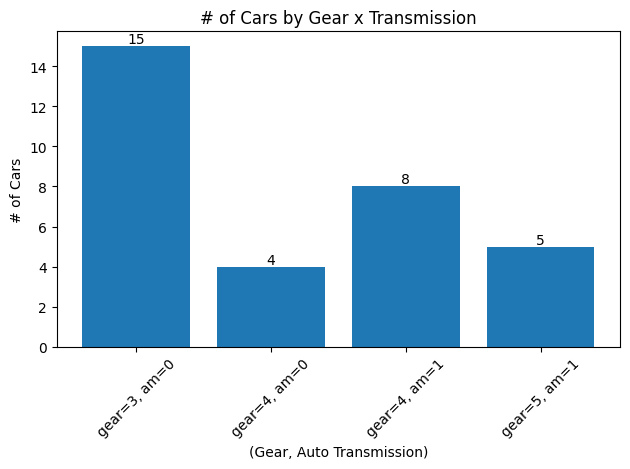

In [92]:
plt.bar(counts["label"], counts["count"])           # 막대그래프
plt.xticks(rotation=45)                             # x축 45도 회전
plt.title("# of Cars by Gear x Transmission")       # 그래프 제목
plt.xlabel("(Gear, Auto Transmission)")             # 그래프 x축 레이블
plt.ylabel("# of Cars")                             # 그래프 y축 레이블
plt.tight_layout()                                  # 서로 겹치지 않게 자동 여백 조절
for idx, value in enumerate(counts["count"]):
    plt.text(
        idx,               # x 위치 (막대 인덱스)
        value,             # y 위치 (막대 높이)
        value,             # 표시할 값 (내부적으로 문자열 처리)
        ha="center",       # 가로 중앙 정렬
        va="bottom"        # 막대 위에 표시
    )
plt.show()                                          # 실제로 화면에 렌더링

## 데이터셋 내 feature간 관계 시각화

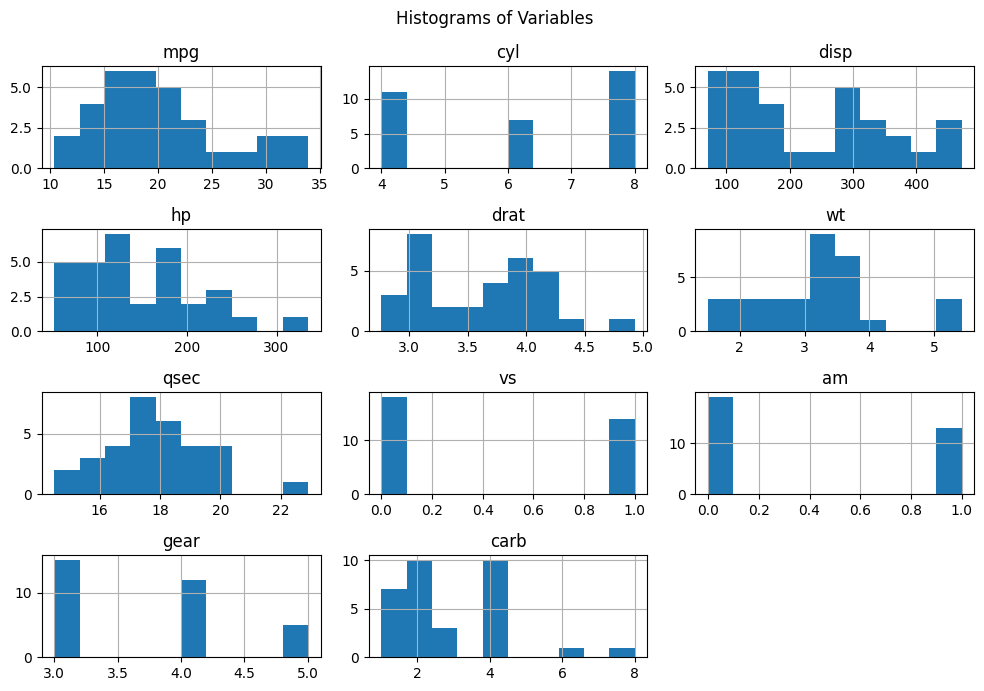

In [93]:
mtcar_data.hist(figsize=(10, 7))
#plt.title("Histograms of Variables")
plt.suptitle("Histograms of Variables")
plt.tight_layout()
plt.show()

hist에서는 title이 동작하지 않음

plt.title은 현재 활성화된 단 하나의 axes에만 제목을 붙이는데,

hist는 여러 axes를 동시에 생성하기 때문

따라서 title 대신 suptitle을 통해 해결

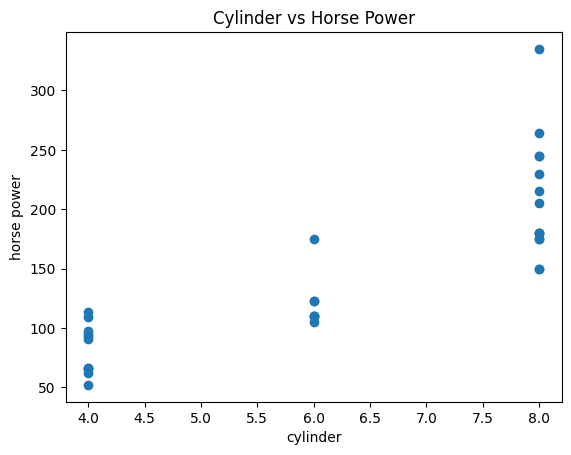

In [94]:
plt.scatter(mtcar_data["cyl"], mtcar_data["hp"])     # scatter 차트
plt.title("Cylinder vs Horse Power")
plt.xlabel("cylinder")
plt.ylabel("horse power")
plt.show()

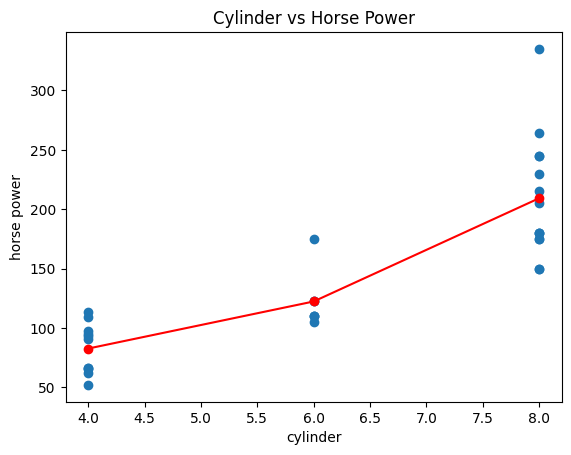

In [95]:
mean_hp = (
    mtcar_data
    .groupby("cyl")["hp"]
    .mean()
    .reset_index()
)


plt.scatter(mtcar_data["cyl"], mtcar_data["hp"])     # scatter 차트

# 평균 라인
plt.plot(
    mean_hp["cyl"],
    mean_hp["hp"],
    marker="o",
    color="red",
    label="Mean Horse Power"
)

plt.title("Cylinder vs Horse Power")
plt.xlabel("cylinder")
plt.ylabel("horse power")
plt.show()

단순히 산점도만 그렸을 때에도 어느 정도 상관관계를 엿볼 수 있지만,

명확히 보이지 않아 실린더 개수와 평균 마력 간의 관계를 그린 선을 하나 추가했다

이로써 더욱이 명확하게 "실린더 수가 더 많은 차량 그룹에서 평균 마력이 더 높다"라는 것을 확인할 수 있다

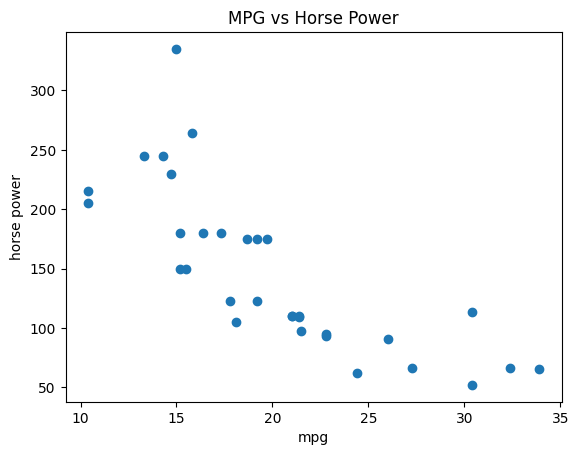

In [96]:
plt.scatter(mtcar_data["mpg"], mtcar_data["hp"])
plt.title("MPG vs Horse Power")
plt.xlabel("mpg")
plt.ylabel("horse power")
plt.show()

위 산점도에서는 완만하게 우하향 형태를 보이는데,

이는 연비가 높아질수록 마력이 낮아지는 경향이 있음을 시사한다

즉 연비와 마력은 음의 상관관계를 가짐을 알 수 있다

In [97]:
corr_table = mtcar_data.iloc[:, 1:].corr()
corr_table

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.000000,-0.852162,-0.847551,-0.776168,0.681172,-0.867659,0.418684,0.664039,0.599832,0.480285,-0.550925
cyl,-0.852162,1.000000,0.902033,0.832447,-0.699938,0.782496,-0.591242,-0.810812,-0.522607,-0.492687,0.526988
disp,-0.847551,0.902033,1.000000,0.790949,-0.710214,0.887980,-0.433698,-0.710416,-0.591227,-0.555569,0.394977
hp,-0.776168,0.832447,0.790949,1.000000,-0.448759,0.658748,-0.708223,-0.723097,-0.243204,-0.125704,0.749812
drat,0.681172,-0.699938,-0.710214,-0.448759,1.000000,-0.712441,0.091205,0.440278,0.712711,0.699610,-0.090790
wt,-0.867659,0.782496,0.887980,0.658748,-0.712441,1.000000,-0.174716,-0.554916,-0.692495,-0.583287,0.427606
qsec,0.418684,-0.591242,-0.433698,-0.708223,0.091205,-0.174716,1.000000,0.744535,-0.229861,-0.212682,-0.656249
vs,0.664039,-0.810812,-0.710416,-0.723097,0.440278,-0.554916,0.744535,1.000000,0.168345,0.206023,-0.569607
am,0.599832,-0.522607,-0.591227,-0.243204,0.712711,-0.692495,-0.229861,0.168345,1.000000,0.794059,0.057534
gear,0.480285,-0.492687,-0.555569,-0.125704,0.699610,-0.583287,-0.212682,0.206023,0.794059,1.000000,0.274073


corr()를 이용해서 간단하게 각 변수들 간의 상관계수를 구할 수 있다

그리고 iloc을 이용해 car_name은 제외하고 진행했다

참고로 corr() 사용 시 주의해야 할 점이 있는데,

일단 값 자체에 집중하기보다 경향에 집중해야 한다는 점과

각 feature가 연속형인지 이산형인지 등 dtype에 따라 어떤 상관계수를 이용할지가 달라진다는 점 등이다

참고로 corr()의 기본값은 피어슨 상관계수이다